# 01 - Data Pipeline: DeepMIMO Channel Generation & Beam Label Computation

**Project:** LWM-LoRA: Scenario-Adaptive mmWave Beam Prediction via LoRA-Tuned Foundation Models for 6G Networks  
**Author:** Nabeegh Khan | MEng ECE Candidate, University of Toronto  
**Portfolio:** [github.com/nabeegh-khan/6g-lwm-beam-prediction](https://github.com/nabeegh-khan/6g-lwm-beam-prediction)

---

## What this notebook does

This notebook builds the complete data pipeline for training a beam prediction model:

1. Generates mmWave channel data for three deployment scenarios using the **DeepMIMO** ray-tracing framework
2. Computes optimal beam labels using a **64-beam DFT codebook** (matching the LWM competition benchmark)
3. Builds a reusable **PyTorch Dataset class** for all downstream notebooks
4. Logs dataset statistics and visualizations to **Weights & Biases**
5. Saves processed data to Google Drive for reuse across all training notebooks

**Why DeepMIMO?** The Large Wireless Model (LWM) foundation model was pre-trained on 1M+ DeepMIMO channels. Using the same data framework ensures our inputs are compatible with LWM's expected format.

**Why three scenarios?** Cross-scenario transfer is the core LoRA experiment — we train on one scenario and use LoRA adapters to cheaply adapt to others.

In [1]:
# install everything we need for data generation and tracking
# note: torch is already available in Colab, so we only add the extras
%pip install -q DeepMIMO wandb peft transformers datasets huggingface_hub \
               h5py seaborn PyYAML --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.3/249.3 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.2/27.2 MB 65.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 680.7/680.7 kB 42.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 70.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 38.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.5/645.5 kB 49.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 15.2 MB/s eta 0:00:00


## Section 1 — Environment Setup

Check GPU availability and set global random seeds for reproducibility.

In [2]:
import os
import sys
import random
import subprocess
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import h5py
import yaml
from pathlib import Path

# ---- reproducibility ----
# picking 42 because every ML tutorial uses 42 and at this point
# it's basically a tradition
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ---- device check ----
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("WARNING: no GPU detected — training cells will be slow")

print(f"PyTorch version: {torch.__version__}")

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB
PyTorch version: 2.10.0+cu128


## Section 2 — Google Drive Mount & Project Paths

Mount Drive to persist data, model checkpoints, and figures between sessions.
The project data folder will be at `/content/drive/MyDrive/6g-lwm-beam-prediction/`.

In [3]:
from google.colab import drive
drive.mount("/content/drive")

# change DRIVE_ROOT if you keep your Colab projects somewhere other than MyDrive root
DRIVE_ROOT = Path("/content/drive/MyDrive/6g-lwm-beam-prediction")
DATA_DIR   = DRIVE_ROOT / "data"
RAW_DIR    = DATA_DIR / "raw"
PROC_DIR   = DATA_DIR / "processed"
CKPT_DIR   = DRIVE_ROOT / "checkpoints"
FIG_DIR    = DRIVE_ROOT / "figures"

for d in [RAW_DIR, PROC_DIR, CKPT_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Drive mounted. Project directory structure:")
for d in [DRIVE_ROOT, DATA_DIR, RAW_DIR, PROC_DIR, CKPT_DIR, FIG_DIR]:
    print(f"  {'OK' if d.exists() else 'MISSING'} → {d}")

Mounted at /content/drive
Drive mounted. Project directory structure:
  OK → /content/drive/MyDrive/6g-lwm-beam-prediction
  OK → /content/drive/MyDrive/6g-lwm-beam-prediction/data
  OK → /content/drive/MyDrive/6g-lwm-beam-prediction/data/raw
  OK → /content/drive/MyDrive/6g-lwm-beam-prediction/data/processed
  OK → /content/drive/MyDrive/6g-lwm-beam-prediction/checkpoints
  OK → /content/drive/MyDrive/6g-lwm-beam-prediction/figures


## Section 3 — Weights & Biases Setup

W&B will track every experiment across all notebooks in this project.
We initialize a run here specifically to log the dataset artifact —
later notebooks will create their own runs for training experiments.

In [4]:
import wandb

# W&B will prompt for your API key — paste it in when asked
# find your key at https://wandb.ai/authorize
wandb.login()

run = wandb.init(
    project="6g-lwm-beam-prediction",
    name="01_data_pipeline",
    tags=["data", "deepmimo", "preprocessing"],
    config={
        "scenarios": ["O1_28", "O1_60", "Boston5G"],
        "n_bs_antennas": 64,
        "n_subcarriers": 32,
        "n_beams": 64,
        "seed": SEED,
    },
    notes="Generate DeepMIMO channels for 3 scenarios, compute DFT beam labels"
)

print(f"W&B run: {run.name}")
print(f"W&B project URL: {run.url}")

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: nabeegh-khan (nabeegh-khan-university-of-toronto) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


W&B run: 01_data_pipeline
W&B project URL: https://wandb.ai/nabeegh-khan-university-of-toronto/6g-lwm-beam-prediction/runs/mtex4ftj


## Section 4 — Clone LWM Repository

The Large Wireless Model (LWM) is hosted on HuggingFace at `wi-lab/lwm-v1.1`.
We clone it directly into the Colab runtime so we can import its custom
model class, tokenizer, and data loading utilities in later notebooks.

We also inspect the repo structure so we know exactly what files are available
before we try to use them in Notebook 02.

In [5]:
import subprocess

LWM_DIR = "/content/LWM"

# clone the repo if it's not already there
if not os.path.exists(LWM_DIR):
    print("Cloning wi-lab/lwm-v1.1 from HuggingFace Hub...")
    result = subprocess.run(
        ["git", "clone", "https://huggingface.co/wi-lab/lwm-v1.1", LWM_DIR],
        capture_output=True, text=True
    )
    if result.returncode != 0:
        print("ERROR:", result.stderr)
    else:
        print("Cloned successfully.")
else:
    print("LWM repo already exists at", LWM_DIR)

# add to Python path so we can import from it
if LWM_DIR not in sys.path:
    sys.path.insert(0, LWM_DIR)

# show what files are in there
print("\nLWM repo contents:")
for f in sorted(os.listdir(LWM_DIR)):
    print(f"  {f}")

Cloning wi-lab/lwm-v1.1 from HuggingFace Hub...
Cloned successfully.

LWM repo contents:
  .git
  .gitattributes
  .gitignore
  README.md
  config.json
  downstream.py
  images
  inference.py
  input_preprocess.py
  lwm_model.py
  main.py
  models
  train.py
  utils.py


In [6]:
# read the config and key source files so we understand the API
# before we try to call anything in later notebooks

print("=" * 60)
print("config.json")
print("=" * 60)
with open(f"{LWM_DIR}/config.json") as f:
    print(f.read())

print("\n" + "=" * 60)
print("models/ directory contents")
print("=" * 60)
for f in sorted(os.listdir(f"{LWM_DIR}/models")):
    size_mb = os.path.getsize(f"{LWM_DIR}/models/{f}") / 1e6
    print(f"  {f}  ({size_mb:.2f} MB)")

print("\n" + "=" * 60)
print("input_preprocess.py  (first 60 lines)")
print("=" * 60)
with open(f"{LWM_DIR}/input_preprocess.py") as f:
    lines = f.readlines()
for i, line in enumerate(lines[:60], 1):
    print(f"{i:3d}  {line}", end="")

print("\n" + "=" * 60)
print("lwm_model.py  (first 60 lines)")
print("=" * 60)
with open(f"{LWM_DIR}/lwm_model.py") as f:
    lines = f.readlines()
for i, line in enumerate(lines[:60], 1):
    print(f"{i:3d}  {line}", end="")

config.json
{
  "architectures": ["LWM-v1.1"],
  "hidden_size": 128,
  "num_attention_heads": 8,
  "num_hidden_layers": 12
}


models/ directory contents
  model.pth  (9.96 MB)

input_preprocess.py  (first 60 lines)
  1  # -*- coding: utf-8 -*-
  2  """
  3  Created on Fri Sep 13 16:13:29 2024
  4  
  5  This script generates preprocessed data from wireless communication scenarios, 
  6  including channel generation, patch generation, masking, and preparing raw
  7  channels for the Transformer-based LWM model. 
  8  
  9  @author: Sadjad Alikhani
 10  """
 11  import numpy as np
 12  import os
 13  from tqdm import tqdm
 14  import time
 15  import pickle
 16  import DeepMIMOv3
 17  import torch
 18  from collections import defaultdict
 19  from utils import generate_gaussian_noise, plot_coverage
 20  #%% Scenarios List
 21  def scenarios_list():
 22      scen_list = np.array([
 23          'city_0_newyork', 
 24          'city_1_losangeles', 
 25          'city_2_chicago', 
 26      

In [7]:
# read the rest of the key files before we commit to a data approach
# need to understand the full pipeline before generating anything

print("=" * 60)
print("input_preprocess.py  (lines 60–150)")
print("=" * 60)
with open(f"{LWM_DIR}/input_preprocess.py") as f:
    lines = f.readlines()
for i, line in enumerate(lines[60:150], 61):
    print(f"{i:3d}  {line}", end="")

print("\n" + "=" * 60)
print("main.py  (full file)")
print("=" * 60)
with open(f"{LWM_DIR}/main.py") as f:
    lines = f.readlines()
for i, line in enumerate(lines, 1):
    print(f"{i:3d}  {line}", end="")

print("\n" + "=" * 60)
print("downstream.py  (full file)")
print("=" * 60)
with open(f"{LWM_DIR}/downstream.py") as f:
    lines = f.readlines()
for i, line in enumerate(lines, 1):
    print(f"{i:3d}  {line}", end="")

input_preprocess.py  (lines 60–150)
 61          'asu_campus1_v19',
 62          'asu_campus1_v20',
 63          'Boston5G_3p5_v1',
 64          'Boston5G_3p5_v2',
 65          'Boston5G_3p5_v3',
 66          'Boston5G_3p5_v4',
 67          'Boston5G_3p5_v5',
 68          'Boston5G_3p5_v6',
 69          'Boston5G_3p5_v7',
 70          'Boston5G_3p5_v8',
 71          'Boston5G_3p5_v9',
 72          'Boston5G_3p5_v10',
 73          'Boston5G_3p5_v11',
 74          'Boston5G_3p5_v12',
 75          'Boston5G_3p5_v13',
 76          'Boston5G_3p5_v14',
 77          'Boston5G_3p5_v15',
 78          'Boston5G_3p5_v16',
 79          'Boston5G_3p5_v17',
 80          'Boston5G_3p5_v18',
 81          'Boston5G_3p5_v19',
 82          'Boston5G_3p5_v20',
 83          'O1_3p5_v1',
 84          'O1_3p5_v2',
 85          'O1_3p5_v3',
 86          'O1_3p5_v4',
 87          'O1_3p5_v5',
 88          'O1_3p5_v6',
 89          'O1_3p5_v7',
 90          'O1_3p5_v8',
 91          'O1_3p5_v9',
 92          'O

In [8]:
# need to read the rest of input_preprocess.py and inference.py
# before we write any data generation code

print("=" * 60)
print("input_preprocess.py  (lines 150–300)")
print("=" * 60)
with open(f"{LWM_DIR}/input_preprocess.py") as f:
    lines = f.readlines()
for i, line in enumerate(lines[150:300], 151):
    print(f"{i:3d}  {line}", end="")

print("\n" + "=" * 60)
print("input_preprocess.py  (lines 300–end)")
print("=" * 60)
for i, line in enumerate(lines[300:], 301):
    print(f"{i:3d}  {line}", end="")

print("\n" + "=" * 60)
print("inference.py  (full file)")
print("=" * 60)
with open(f"{LWM_DIR}/inference.py") as f:
    lines = f.readlines()
for i, line in enumerate(lines, 1):
    print(f"{i:3d}  {line}", end="")

print("\n" + "=" * 60)
print("utils.py  (full file)")
print("=" * 60)
with open(f"{LWM_DIR}/utils.py") as f:
    lines = f.readlines()
for i, line in enumerate(lines, 1):
    print(f"{i:3d}  {line}", end="")

input_preprocess.py  (lines 150–300)
151                      print(f"Data loaded from {file_name}")
152                      deepmimo_data.append(data)
153              
154          cleaned_deepmimo_data = [deepmimo_data_cleaning(deepmimo_data[scenario_idx]) for scenario_idx in range(len(deepmimo_data))] #n_scenarios*n_bs_idxs
155          patches = [patch_maker(cleaned_deepmimo_data[scenario_idx], N_ROWS, N_COLUMNS) for scenario_idx in range(len(deepmimo_data))]
156          raw_chs = torch.tensor(cleaned_deepmimo_data[0]).squeeze(1)
157          raw_chs = raw_chs.view(raw_chs.size(0), -1)
158          raw_chs = torch.hstack((raw_chs.real, raw_chs.imag))
159          
160          if task:
161              labels = [label_gen(task, deepmimo_data[scenario_idx], selected_scenario_names[scenario_idx], n_beams=n_beams) for scenario_idx in range(len(deepmimo_data))]
162              return patches, torch.tensor(labels[0]), raw_chs.view(raw_chs.size(0), -1)
163          else:
164         

In [9]:
# check both packages before committing to a data strategy
print("=" * 55)
print("Test 1: can we install DeepMIMOv3?")
print("=" * 55)
result = subprocess.run(
    ["pip", "install", "DeepMIMOv3", "-q"],
    capture_output=True, text=True
)
print(result.stdout[-500:] if result.stdout else "no stdout")
print(result.stderr[-500:] if result.stderr else "no stderr")

print("\n" + "=" * 55)
print("Test 2: can we import DeepMIMOv3?")
print("=" * 55)
try:
    import DeepMIMOv3
    print("DeepMIMOv3 imported successfully")
    print(dir(DeepMIMOv3))
except ImportError as e:
    print(f"Import failed: {e}")

print("\n" + "=" * 55)
print("Test 3: what does standalone DeepMIMO expose?")
print("=" * 55)
import DeepMIMO
print(dir(DeepMIMO))
print("\nDeepMIMO version:", getattr(DeepMIMO, "__version__", "unknown"))

Test 1: can we install DeepMIMOv3?
no stdout
no stderr

Test 2: can we import DeepMIMOv3?
DeepMIMOv3 imported successfully
['DeepMIMOSionnaAdapter', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', 'ant_indices', 'ant_patterns', 'array_response', 'construct_deepmimo', 'consts', 'default_params', 'generate_data', 'generator', 'params', 'sionna_adapter', 'utils']

Test 3: what does standalone DeepMIMO expose?


ModuleNotFoundError: No module named 'DeepMIMO'

In [10]:
# understand DeepMIMOv3's API and whether it has auto-download
import DeepMIMOv3

print("=" * 55)
print("default_params()")
print("=" * 55)
params = DeepMIMOv3.default_params()
for k, v in params.items():
    print(f"  {k}: {v}")

print("\n" + "=" * 55)
print("DeepMIMOv3 package location")
print("=" * 55)
print(DeepMIMOv3.__file__)

print("\n" + "=" * 55)
print("Files in DeepMIMOv3 package directory")
print("=" * 55)
import pathlib
pkg_dir = pathlib.Path(DeepMIMOv3.__file__).parent
for f in sorted(pkg_dir.rglob("*.py")):
    print(f"  {f.relative_to(pkg_dir)}")

print("\n" + "=" * 55)
print("generator.py  (first 80 lines — looking for download logic)")
print("=" * 55)
gen_file = pkg_dir / "generator.py"
if gen_file.exists():
    lines = gen_file.read_text().splitlines()
    for i, line in enumerate(lines[:80], 1):
        print(f"{i:3d}  {line}")
else:
    print("generator.py not found — checking other files")
    for f in sorted(pkg_dir.glob("*.py")):
        print(f"  {f.name}")

default_params()
  dataset_folder: ./Raytracing_scenarios
  scenario: O1_60
  dynamic_scenario_scenes: [1]
  num_paths: 5
  active_BS: [1]
  user_rows: [1]
  user_subsampling: 1
  bs_antenna: {'shape': array([8, 4]), 'spacing': 0.5, 'rotation': array([0, 0, 0]), 'FoV': array([360, 180]), 'radiation_pattern': 'isotropic'}
  ue_antenna: {'shape': array([4, 2]), 'spacing': 0.5, 'rotation': array([0, 0, 0]), 'FoV': array([360, 180]), 'radiation_pattern': 'isotropic'}
  enable_doppler: 0
  enable_dual_polar: 0
  enable_BS2BS: 1
  OFDM_channels: 1
  OFDM: {'subcarriers': 512, 'selected_subcarriers': array([0]), 'bandwidth': 0.05, 'RX_filter': 0}

DeepMIMOv3 package location
/usr/local/lib/python3.12/dist-packages/DeepMIMOv3/__init__.py

Files in DeepMIMOv3 package directory
  __init__.py
  ant_patterns.py
  construct_deepmimo.py
  consts.py
  generator.py
  params.py
  raytracing_v2.py
  raytracing_v3.py
  sionna_adapter.py
  utils.py
  visualization.py

generator.py  (first 80 lines — looki

In [11]:
# check if deepmimo.net has direct download links we can use from Colab
# also check if the LWM repo has any download helper script we missed

print("=" * 55)
print("Any download scripts in LWM repo?")
print("=" * 55)
for f in sorted(os.listdir(LWM_DIR)):
    if any(word in f.lower() for word in ["download", "setup", "data", "get"]):
        print(f"  FOUND: {f}")
        with open(f"{LWM_DIR}/{f}") as fh:
            print(fh.read())
print("  (done)")

print("\n" + "=" * 55)
print("Try wget on known DeepMIMO scenario URLs")
print("=" * 55)

# DeepMIMO hosts scenarios as zip files — test if O1_3p5 is reachable
test_urls = [
    "https://www.deepmimo.net/wp-content/uploads/scenarios/O1_3p5.zip",
    "https://deepmimo.net/scenarios/o1-scenario/",
    "https://data.deepmimo.net/O1_3p5.zip",
]
import urllib.request
for url in test_urls:
    try:
        req = urllib.request.Request(url, method="HEAD")
        with urllib.request.urlopen(req, timeout=5) as resp:
            print(f"  REACHABLE ({resp.status}): {url}")
    except Exception as e:
        print(f"  FAILED: {url}  → {e}")

Any download scripts in LWM repo?
  (done)

Try wget on known DeepMIMO scenario URLs
  REACHABLE (200): https://www.deepmimo.net/wp-content/uploads/scenarios/O1_3p5.zip
  REACHABLE (200): https://deepmimo.net/scenarios/o1-scenario/
  FAILED: https://data.deepmimo.net/O1_3p5.zip  → <urlopen error [Errno -2] Name or service not known>


In [12]:
import urllib.request

# test URL pattern for several candidate scenarios
# we'll pick 3 with consistent antenna/subcarrier counts and small file sizes
candidate_scenarios = [
    "O1_3p5",
    "Boston5G_3p5",
    "asu_campus1",
    "city_0_newyork",
    "city_6_miami",
    "city_11_santaclara",
    "city_15_indianapolis",
]

BASE_URL = "https://www.deepmimo.net/wp-content/uploads/scenarios"

print(f"{'Scenario':<30} {'Status':<12} {'Size (MB)'}")
print("-" * 55)
for sc in candidate_scenarios:
    url = f"{BASE_URL}/{sc}.zip"
    try:
        req = urllib.request.Request(url, method="HEAD")
        with urllib.request.urlopen(req, timeout=8) as resp:
            size_bytes = resp.headers.get("Content-Length")
            size_mb = int(size_bytes) / 1e6 if size_bytes else "unknown"
            print(f"{sc:<30} {'OK':<12} {size_mb}")
    except Exception as e:
        print(f"{sc:<30} {'FAILED':<12} {e}")

Scenario                       Status       Size (MB)
-------------------------------------------------------
O1_3p5                         OK           0.000892
Boston5G_3p5                   OK           0.000892
asu_campus1                    OK           0.000892
city_0_newyork                 OK           0.000892
city_6_miami                   OK           0.000892
city_11_santaclara             OK           0.000892
city_15_indianapolis           OK           0.000892


In [13]:
import urllib.request

# actually download the first ~2000 bytes of one file to see what it really is
url = f"{BASE_URL}/O1_3p5.zip"

req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
with urllib.request.urlopen(req, timeout=10) as resp:
    first_bytes = resp.read(2000)
    final_url   = resp.url
    status      = resp.status
    headers     = dict(resp.headers)

print(f"Status: {status}")
print(f"Final URL (after redirects): {final_url}")
print(f"Content-Type: {headers.get('Content-Type', 'unknown')}")
print(f"Content-Length: {headers.get('Content-Length', 'unknown')}")
print(f"\nFirst 500 bytes (raw):")
print(first_bytes[:500])
print(f"\nFirst 500 bytes decoded as utf-8 (ignore errors):")
print(first_bytes[:500].decode("utf-8", errors="replace"))

Status: 200
Final URL (after redirects): https://www.deepmimo.net/wp-content/uploads/scenarios/O1_3p5.zip
Content-Type: text/html; charset=UTF-8
Content-Length: 892

First 500 bytes (raw):
b'<!doctype html>\n<html lang="en">\n\n<head>\n  <meta charset="UTF-8" />\n  <link rel="icon" type="image/png" href="/favicon_new.png">\n  <meta name="viewport" content="width=device-width, initial-scale=1.0" />\n  <link rel="preconnect" href="https://fonts.googleapis.com">\n  <link rel="preconnect" href="https://fonts.gstatic.com" crossorigin>\n  <link\n    href="https://fonts.googleapis.com/css2?family=Inter:ital,opsz,wght@0,14..32,100..900;1,14..32,100..900&family=Plus+Jakarta+Sans:ital,wght@0,200..800;1'

First 500 bytes decoded as utf-8 (ignore errors):
<!doctype html>
<html lang="en">

<head>
  <meta charset="UTF-8" />
  <link rel="icon" type="image/png" href="/favicon_new.png">
  <meta name="viewport" content="width=device-width, initial-scale=1.0" />
  <link rel="preconnect" href="https://fon

In [14]:
import urllib.request
import json

# check if wi-lab or sadjadalikhani has scenario datasets on HuggingFace
# the original LWM v1.0 HF card had a clone_dataset_scenario function
# suggesting scenarios might be hosted there

hf_urls_to_try = [
    # check for dataset repos on HuggingFace
    "https://huggingface.co/api/models/wi-lab/lwm-v1.1",
    "https://huggingface.co/api/datasets?author=wi-lab",
    "https://huggingface.co/api/datasets?author=sadjadalikhani",
    "https://huggingface.co/api/models?author=wi-lab",
]

for url in hf_urls_to_try:
    try:
        req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
        with urllib.request.urlopen(req, timeout=8) as resp:
            data = json.loads(resp.read().decode())
            if isinstance(data, list):
                print(f"\n{url}")
                for item in data:
                    name = item.get('id') or item.get('modelId') or str(item)
                    print(f"  → {name}")
            else:
                print(f"\n{url}")
                print(f"  keys: {list(data.keys()) if isinstance(data, dict) else data}")
    except Exception as e:
        print(f"\nFAILED: {url} → {e}")


https://huggingface.co/api/models/wi-lab/lwm-v1.1
  keys: ['_id', 'id', 'private', 'pipeline_tag', 'library_name', 'tags', 'downloads', 'likes', 'modelId', 'author', 'sha', 'lastModified', 'gated', 'disabled', 'model-index', 'config', 'cardData', 'transformersInfo', 'siblings', 'spaces', 'createdAt', 'usedStorage']

https://huggingface.co/api/datasets?author=wi-lab
  → wi-lab/lwm

https://huggingface.co/api/datasets?author=sadjadalikhani

https://huggingface.co/api/models?author=wi-lab
  → wi-lab/lwm
  → wi-lab/lwm-v1.1
  → wi-lab/lwm-competition-2025
  → wi-lab/lwm-spectro
  → wi-lab/lwm-temporal


In [15]:
# wi-lab/lwm is listed as a HuggingFace DATASET — check what files it contains
# this might be exactly the scenario data we need

urls_to_check = [
    "https://huggingface.co/api/datasets/wi-lab/lwm",
    "https://huggingface.co/api/datasets/wi-lab/lwm/tree/main",
]

for url in urls_to_check:
    try:
        req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
        with urllib.request.urlopen(req, timeout=10) as resp:
            data = json.loads(resp.read().decode())
            print(f"\n{url}")
            if isinstance(data, list):
                for item in data:
                    name = item.get('path') or item.get('rfilename') or str(item)
                    size = item.get('size', '')
                    print(f"  → {name}  {size}")
            elif isinstance(data, dict):
                # check siblings for file list
                siblings = data.get('siblings', [])
                if siblings:
                    print(f"  Files ({len(siblings)}):")
                    for s in siblings:
                        print(f"    {s.get('rfilename', s)}")
                else:
                    print(f"  keys: {list(data.keys())}")
    except Exception as e:
        print(f"FAILED: {url} → {e}")


https://huggingface.co/api/datasets/wi-lab/lwm
  Files (107):
    .gitattributes
    .gitignore
    README.md
    beam_prediction_challenge/test/bp_data_test.p
    beam_prediction_challenge/train/bp_data_train.p
    beam_prediction_challenge/train/bp_label_train.p
    city_11_santaclara/BS1_BS.mat
    city_11_santaclara/BS1_UE_0-5358.mat
    city_11_santaclara/BS2_BS.mat
    city_11_santaclara/BS2_UE_0-5358.mat
    city_11_santaclara/BS3_BS.mat
    city_11_santaclara/BS3_UE_0-5358.mat
    city_11_santaclara/osm_gps_origin.txt
    city_11_santaclara/params.mat
    city_12_fortworth/BS1_BS.mat
    city_12_fortworth/BS1_UE_0-6192.mat
    city_12_fortworth/BS2_BS.mat
    city_12_fortworth/BS2_UE_0-6192.mat
    city_12_fortworth/BS3_BS.mat
    city_12_fortworth/BS3_UE_0-6192.mat
    city_12_fortworth/osm_gps_origin.txt
    city_12_fortworth/params.mat
    city_15_indianapolis/BS1_BS.mat
    city_15_indianapolis/BS1_UE_0-6320.mat
    city_15_indianapolis/BS2_BS.mat
    city_15_indianapolis/

In [16]:
from huggingface_hub import hf_hub_download, list_repo_files
import os

# check file sizes for everything we might want to download
# huggingface_hub gives us metadata without downloading

from huggingface_hub import HfApi
api = HfApi()

files = api.list_repo_files(repo_id="wi-lab/lwm", repo_type="dataset")

# get size info via the api
repo_info = api.repo_info(repo_id="wi-lab/lwm", repo_type="dataset")
siblings = repo_info.siblings

print(f"{'File':<60} {'Size (MB)'}")
print("-" * 75)
for s in siblings:
    size_mb = s.size / 1e6 if s.size else 0
    # only show files we actually care about
    if any(x in s.rfilename for x in [
        "beam_prediction", "city_11", "city_15", "city_6_miami",
        "mmWave", "santaclara", "indianapolis", "miami"
    ]):
        print(f"{s.rfilename:<60} {size_mb:.1f}")

File                                                         Size (MB)
---------------------------------------------------------------------------
beam_prediction_challenge/test/bp_data_test.p                0.0
beam_prediction_challenge/train/bp_data_train.p              0.0
beam_prediction_challenge/train/bp_label_train.p             0.0
city_11_santaclara/BS1_BS.mat                                0.0
city_11_santaclara/BS1_UE_0-5358.mat                         0.0
city_11_santaclara/BS2_BS.mat                                0.0
city_11_santaclara/BS2_UE_0-5358.mat                         0.0
city_11_santaclara/BS3_BS.mat                                0.0
city_11_santaclara/BS3_UE_0-5358.mat                         0.0
city_11_santaclara/osm_gps_origin.txt                        0.0
city_11_santaclara/params.mat                                0.0
city_15_indianapolis/BS1_BS.mat                              0.0
city_15_indianapolis/BS1_UE_0-6320.mat                       0.0
city_15_

In [17]:
from huggingface_hub import hf_hub_download
import pickle

# download the beam prediction challenge files — these might already be
# tokenized in exactly the format LWM expects
print("Downloading beam prediction challenge files from wi-lab/lwm dataset...")

bp_train_data_path = hf_hub_download(
    repo_id="wi-lab/lwm",
    filename="beam_prediction_challenge/train/bp_data_train.p",
    repo_type="dataset",
    local_dir="/content/lwm_dataset"
)
bp_train_label_path = hf_hub_download(
    repo_id="wi-lab/lwm",
    filename="beam_prediction_challenge/train/bp_label_train.p",
    repo_type="dataset",
    local_dir="/content/lwm_dataset"
)
bp_test_data_path = hf_hub_download(
    repo_id="wi-lab/lwm",
    filename="beam_prediction_challenge/test/bp_data_test.p",
    repo_type="dataset",
    local_dir="/content/lwm_dataset"
)

print("Downloaded. Inspecting contents...")

# load and inspect
with open(bp_train_data_path, "rb") as f:
    bp_train_data = pickle.load(f)

with open(bp_train_label_path, "rb") as f:
    bp_train_labels = pickle.load(f)

with open(bp_test_data_path, "rb") as f:
    bp_test_data = pickle.load(f)

print(f"\nbp_data_train type:  {type(bp_train_data)}")
print(f"bp_label_train type: {type(bp_train_labels)}")
print(f"bp_data_test type:   {type(bp_test_data)}")

# dig into the structure
if isinstance(bp_train_data, dict):
    print(f"\nbp_data_train keys: {list(bp_train_data.keys())}")
    for k, v in bp_train_data.items():
        vtype = type(v)
        vshape = v.shape if hasattr(v, 'shape') else (len(v) if hasattr(v, '__len__') else 'scalar')
        print(f"  [{k}]: {vtype.__name__}, shape/len={vshape}")
elif isinstance(bp_train_data, (list, tuple)):
    print(f"\nbp_data_train length: {len(bp_train_data)}")
    print(f"  first element type: {type(bp_train_data[0])}")
    if hasattr(bp_train_data[0], 'shape'):
        print(f"  first element shape: {bp_train_data[0].shape}")
elif hasattr(bp_train_data, 'shape'):
    print(f"\nbp_data_train shape: {bp_train_data.shape}, dtype: {bp_train_data.dtype}")

print(f"\nbp_label_train: {type(bp_train_labels)}", end="")
if hasattr(bp_train_labels, 'shape'):
    print(f", shape={bp_train_labels.shape}, dtype={bp_train_labels.dtype}")
    print(f"  label range: {bp_train_labels.min()} to {bp_train_labels.max()}")
    print(f"  unique labels: {len(np.unique(bp_train_labels))}")
elif hasattr(bp_train_labels, '__len__'):
    print(f", length={len(bp_train_labels)}")

beam_prediction_challenge/train/bp_data_(…):   0%|          | 0.00/5.10M [00:00<?, ?B/s]

bp_label_train.p:   0%|          | 0.00/5.37k [00:00<?, ?B/s]

beam_prediction_challenge/test/bp_data_t(…):   0%|          | 0.00/20.4M [00:00<?, ?B/s]

Downloaded. Inspecting contents...

bp_data_train type:  <class 'numpy.ndarray'>
bp_label_train type: <class 'torch.Tensor'>
bp_data_test type:   <class 'numpy.ndarray'>

bp_data_train shape: (622, 32, 32), dtype: float64

bp_label_train: <class 'torch.Tensor'>, shape=torch.Size([622]), dtype=torch.int64
  label range: 0 to 63
  unique labels: 62


In [18]:
# inspect test data shape and check what one raw .mat scenario file contains
print("=" * 55)
print("Test data shape")
print("=" * 55)
print(f"bp_data_test shape: {bp_test_data.shape}, dtype: {bp_test_data.dtype}")
print(f"patch shape per sample: {bp_test_data.shape[1:]}")
print(f"Total samples across train+test: {len(bp_train_data) + len(bp_test_data)}")

# download one .mat scenario file to understand raw format
print("\n" + "=" * 55)
print("Download one raw .mat file from city_6_miami")
print("=" * 55)

mat_path = hf_hub_download(
    repo_id="wi-lab/lwm",
    filename="city_6_miami/params.mat",
    repo_type="dataset",
    local_dir="/content/lwm_dataset"
)

import scipy.io as sio
mat = sio.loadmat(mat_path)
print(f"params.mat keys: {[k for k in mat.keys() if not k.startswith('_')]}")
for k, v in mat.items():
    if not k.startswith('_'):
        print(f"  {k}: {type(v).__name__}, {v if np.array(v).size < 10 else str(np.array(v).shape)}")

# also check file size of one UE channel file before downloading it
print("\n" + "=" * 55)
print("Check UE channel file sizes across scenarios")
print("=" * 55)
files_to_check = [
    "city_6_miami/BS1_UE_0-42984.mat",
    "city_11_santaclara/BS1_UE_0-5358.mat",
    "city_15_indianapolis/BS1_UE_0-6320.mat",
    "mmWave_scenarios/santaclara_28ghz/BS1_UE_0-5358.mat",
    "mmWave_scenarios/indianapolis_28ghz/BS1_UE_0-6320.mat",
]
for fname in files_to_check:
    for s in siblings:
        if s.rfilename == fname:
            # LFS files — try to get actual size via HF resolve URL
            print(f"  {fname}: listed size = {s.size} bytes (LFS pointer)")

Test data shape
bp_data_test shape: (2491, 32, 32), dtype: float64
patch shape per sample: (32, 32)
Total samples across train+test: 3113

Download one raw .mat file from city_6_miami


params.mat:   0%|          | 0.00/672 [00:00<?, ?B/s]

params.mat keys: ['version', 'carrier_freq', 'transmit_power', 'user_grids', 'num_BS', 'dual_polar_available', 'doppler_available']
  version: ndarray, [[2]]
  carrier_freq: ndarray, [[3.5e+09]]
  transmit_power: ndarray, [[0.]]
  user_grids: ndarray, [[  1. 199. 216.]]
  num_BS: ndarray, [[3]]
  dual_polar_available: ndarray, [[0]]
  doppler_available: ndarray, [[0]]

Check UE channel file sizes across scenarios
  city_6_miami/BS1_UE_0-42984.mat: listed size = None bytes (LFS pointer)
  city_11_santaclara/BS1_UE_0-5358.mat: listed size = None bytes (LFS pointer)
  city_15_indianapolis/BS1_UE_0-6320.mat: listed size = None bytes (LFS pointer)
  mmWave_scenarios/santaclara_28ghz/BS1_UE_0-5358.mat: listed size = None bytes (LFS pointer)
  mmWave_scenarios/indianapolis_28ghz/BS1_UE_0-6320.mat: listed size = None bytes (LFS pointer)


In [19]:
import time

# try downloading the smallest raw scenario — santaclara has 5358 users
# which is manageable. time it so we know what we're dealing with

print("Attempting to download city_11_santaclara BS1 UE channels...")
print("(watching download size as it streams)")

t0 = time.time()
try:
    ue_mat_path = hf_hub_download(
        repo_id="wi-lab/lwm",
        filename="city_11_santaclara/BS1_UE_0-5358.mat",
        repo_type="dataset",
        local_dir="/content/lwm_dataset"
    )
    elapsed = time.time() - t0
    file_size_mb = os.path.getsize(ue_mat_path) / 1e6
    print(f"\nDownloaded in {elapsed:.1f}s")
    print(f"Actual file size: {file_size_mb:.1f} MB")
    print(f"Saved to: {ue_mat_path}")

    # peek inside to understand structure
    mat_data = sio.loadmat(ue_mat_path)
    print(f"\nKeys: {[k for k in mat_data.keys() if not k.startswith('_')]}")
    for k, v in mat_data.items():
        if not k.startswith('_'):
            arr = np.array(v)
            print(f"  {k}: shape={arr.shape}, dtype={arr.dtype}")

except Exception as e:
    print(f"Download failed: {e}")

Attempting to download city_11_santaclara BS1 UE channels...
(watching download size as it streams)


city_11_santaclara/BS1_UE_0-5358.mat:   0%|          | 0.00/1.03M [00:00<?, ?B/s]


Downloaded in 1.1s
Actual file size: 1.0 MB
Saved to: /content/lwm_dataset/city_11_santaclara/BS1_UE_0-5358.mat

Keys: ['channels', 'rx_locs', 'tx_loc']
  channels: shape=(1, 5358), dtype=object
  rx_locs: shape=(5358, 5), dtype=float32
  tx_loc: shape=(1, 3), dtype=float32


In [20]:
# dig into the channels cell array — each element is a complex channel matrix
ch_array = mat_data['channels']
print(f"channels outer shape: {ch_array.shape}, dtype: {ch_array.dtype}")

# MATLAB cell arrays load as object arrays — index into them
first_ch = ch_array[0, 0]
print(f"\nchannels[0,0] type: {type(first_ch)}")
print(f"channels[0,0] shape: {first_ch.shape}")
print(f"channels[0,0] dtype: {first_ch.dtype}")
print(f"channels[0,0] sample values (first antenna, first 4 subcarriers):")
print(first_ch[:4, :4] if first_ch.ndim == 2 else first_ch[:4])

# check a few more to see if shape is consistent
print(f"\nChecking shapes of first 5 channel entries:")
for i in range(5):
    ch = ch_array[0, i]
    print(f"  channels[0,{i}]: shape={ch.shape}, dtype={ch.dtype}")

# check rx_locs to understand location format
print(f"\nrx_locs first 3 rows (user locations):")
print(mat_data['rx_locs'][:3])
print(f"\ntx_loc (BS location):")
print(mat_data['tx_loc'])

# also check scenario_prop for city_11_santaclara
# to confirm n_ant_bs and n_subcarriers match what we see
sys.path.insert(0, LWM_DIR)
from input_preprocess import scenario_prop
props = scenario_prop()
print(f"\nscenario_prop for city_11_santaclara:")
print(f"  {props['city_11_santaclara']}")

channels outer shape: (1, 5358), dtype: object

channels[0,0] type: <class 'numpy.ndarray'>
channels[0,0] shape: (1, 1)
channels[0,0] dtype: [('p', 'O')]
channels[0,0] sample values (first antenna, first 4 subcarriers):
[[(array([[-9.12666e+01, -2.12510e+01, -9.65247e+01],
         [ 7.13215e-07,  7.13590e-07,  7.83073e-07],
         [-8.99316e+01, -9.28250e+01, -1.01208e+02],
         [ 2.02163e+01,  2.02163e+01, -3.02664e-01],
         [ 8.89277e+01,  9.21438e+01,  8.90234e+01],
         [-1.59784e+02, -1.59784e+02, -1.30367e+02],
         [ 9.10723e+01,  9.21438e+01,  9.09766e+01],
         [ 1.00000e+00,  0.00000e+00,  0.00000e+00]], dtype=float32),)]]

Checking shapes of first 5 channel entries:
  channels[0,0]: shape=(1, 1), dtype=[('p', 'O')]
  channels[0,1]: shape=(1, 1), dtype=[('p', 'O')]
  channels[0,2]: shape=(1, 1), dtype=[('p', 'O')]
  channels[0,3]: shape=(1, 1), dtype=[('p', 'O')]
  channels[0,4]: shape=(1, 1), dtype=[('p', 'O')]

rx_locs first 3 rows (user locations):


In [21]:
# strategy recap:
# 1. pre-processed challenge data → use directly as scenario A (already downloaded)
# 2. download 2 more city scenarios raw .mat files → process via DeepMIMOv3 → scenarios B and C
# 3. this gives us 3 scenarios for the LoRA domain adaptation experiment
#
# scenarios chosen:
#   city_11_santaclara  → 32 ant, 32 SC, ~5358 users (small, same SC as challenge data)
#   city_12_fortworth   → 32 ant, 64 SC, ~6192 users (same ant, more subcarriers)
#   city_6_miami        → 16 ant, 32 SC, ~42984 users (larger, different ant count)
#
# DeepMIMOv3 expects: <dataset_folder>/<scenario_name>/<mat files>
# we'll use /content/scenarios/ as dataset_folder

SCENARIOS_DIR = "/content/scenarios"
os.makedirs(SCENARIOS_DIR, exist_ok=True)

# files needed per scenario
scenario_files = {
    "city_11_santaclara": [
        "city_11_santaclara/params.mat",
        "city_11_santaclara/BS1_UE_0-5358.mat",
        "city_11_santaclara/BS2_UE_0-5358.mat",
        "city_11_santaclara/BS3_UE_0-5358.mat",
        "city_11_santaclara/BS1_BS.mat",
        "city_11_santaclara/BS2_BS.mat",
        "city_11_santaclara/BS3_BS.mat",
    ],
    "city_12_fortworth": [
        "city_12_fortworth/params.mat",
        "city_12_fortworth/BS1_UE_0-6192.mat",
        "city_12_fortworth/BS2_UE_0-6192.mat",
        "city_12_fortworth/BS3_UE_0-6192.mat",
        "city_12_fortworth/BS1_BS.mat",
        "city_12_fortworth/BS2_BS.mat",
        "city_12_fortworth/BS3_BS.mat",
    ],
    "city_6_miami": [
        "city_6_miami/params.mat",
        "city_6_miami/BS1_UE_0-42984.mat",
        "city_6_miami/BS2_UE_0-42984.mat",
        "city_6_miami/BS3_UE_0-42984.mat",
        "city_6_miami/BS1_BS.mat",
        "city_6_miami/BS2_BS.mat",
        "city_6_miami/BS3_BS.mat",
    ],
}

print("Downloading scenario files from wi-lab/lwm dataset...")
print("(files go into /content/scenarios/<scenario_name>/)\n")

for scenario_name, files in scenario_files.items():
    dest_dir = os.path.join(SCENARIOS_DIR, scenario_name)
    os.makedirs(dest_dir, exist_ok=True)
    print(f"→ {scenario_name}")
    for fname in files:
        basename = os.path.basename(fname)
        dest_path = os.path.join(dest_dir, basename)
        if os.path.exists(dest_path):
            print(f"   already exists: {basename}")
            continue
        try:
            downloaded = hf_hub_download(
                repo_id="wi-lab/lwm",
                filename=fname,
                repo_type="dataset",
                local_dir="/content/lwm_dataset"
            )
            # copy to the correct DeepMIMOv3 folder structure
            import shutil
            shutil.copy(downloaded, dest_path)
            size_mb = os.path.getsize(dest_path) / 1e6
            print(f"   {basename} ({size_mb:.1f} MB)")
        except Exception as e:
            print(f"   FAILED {basename}: {e}")

print("\nFolder structure:")
for sc in scenario_files:
    files_present = os.listdir(f"{SCENARIOS_DIR}/{sc}")
    print(f"  {sc}/: {sorted(files_present)}")

(files go into /content/scenarios/<scenario_name>/)

→ city_11_santaclara


params.mat:   0%|          | 0.00/672 [00:00<?, ?B/s]

   params.mat (0.0 MB)
   BS1_UE_0-5358.mat (1.0 MB)


BS2_UE_0-5358.mat:   0%|          | 0.00/895k [00:00<?, ?B/s]

   BS2_UE_0-5358.mat (0.9 MB)


...

   BS1_BS.mat (0.0 MB)


BS2_BS.mat:   0%|          | 0.00/1.01k [00:00<?, ?B/s]

   BS2_BS.mat (0.0 MB)


BS3_BS.mat:   0%|          | 0.00/1.42k [00:00<?, ?B/s]

   BS3_BS.mat (0.0 MB)

Folder structure:
  city_11_santaclara/: ['BS1_BS.mat', 'BS1_UE_0-5358.mat', 'BS2_BS.mat', 'BS2_UE_0-5358.mat', 'BS3_BS.mat', 'BS3_UE_0-5358.mat', 'params.mat']
  city_12_fortworth/: ['BS1_BS.mat', 'BS1_UE_0-6192.mat', 'BS2_BS.mat', 'BS2_UE_0-6192.mat', 'BS3_BS.mat', 'BS3_UE_0-6192.mat', 'params.mat']
  city_6_miami/: ['BS1_BS.mat', 'BS1_UE_0-42984.mat', 'BS2_BS.mat', 'BS2_UE_0-42984.mat', 'BS3_BS.mat', 'BS3_UE_0-42984.mat', 'params.mat']


Scenario properties:
  city_11_santaclara: n_ant_bs=32, n_subcarriers=32, n_rows=117, n_per_row=285
  city_12_fortworth: n_ant_bs=32, n_subcarriers=64, n_rows=214, n_per_row=179
  city_6_miami: n_ant_bs=16, n_subcarriers=32, n_rows=199, n_per_row=216

Processing: city_11_santaclara

Generating data for scenario: city_11_santaclara, BS #1
  ERROR: The rows are not selected properly. The available rows in this scenario are in [0, 46]

Processing: city_12_fortworth

Generating data for scenario: city_12_fortworth, BS #1
  ERROR: The rows are not selected properly. The available rows in this scenario are in [0, 85]

Processing: city_6_miami

Generating data for scenario: city_6_miami, BS #1

Basestation 1


Traceback (most recent call last):
  File "/tmp/ipykernel_1745/4288830087.py", line 36, in <cell line: 0>
    patches, labels, raw_chs = tokenizer(
                               ^^^^^^^^^^
  File "/content/LWM/input_preprocess.py", line 178, in tokenizer
    patches, labels, raw_chs = patch_gen(
                               ^^^^^^^^^^
  File "/content/LWM/input_preprocess.py", line 141, in patch_gen
    data, n_ant_bs, n_subcarriers = DeepMIMO_data_gen(scenario_name, bs_idx)
                                    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/LWM/input_preprocess.py", line 306, in DeepMIMO_data_gen
    deepMIMO_dataset = DeepMIMOv3.generate_data(parameters)
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/DeepMIMOv3/generator.py", line 24, in generate_data
    params = validate_params(copy.deepcopy(ext_params))
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/


UE-BS Channels


Generating channels: 100%|██████████| 42984/42984 [00:07<00:00, 5616.59it/s]


Data saved to data/city_6_miami_ant16_sub32_bs1.npy


Computing the channel for each user: 100%|██████████| 42984/42984 [00:00<00:00, 57089.29it/s]


Total number of samples: 10441


Processing items: 100%|██████████| 10441/10441 [00:00<00:00, 10692.64it/s]


  patches shape: torch.Size([10441, 33, 32])
  labels shape:  torch.Size([10441]), range: 0–62
  raw_chs shape: torch.Size([10441, 1024])

Done.


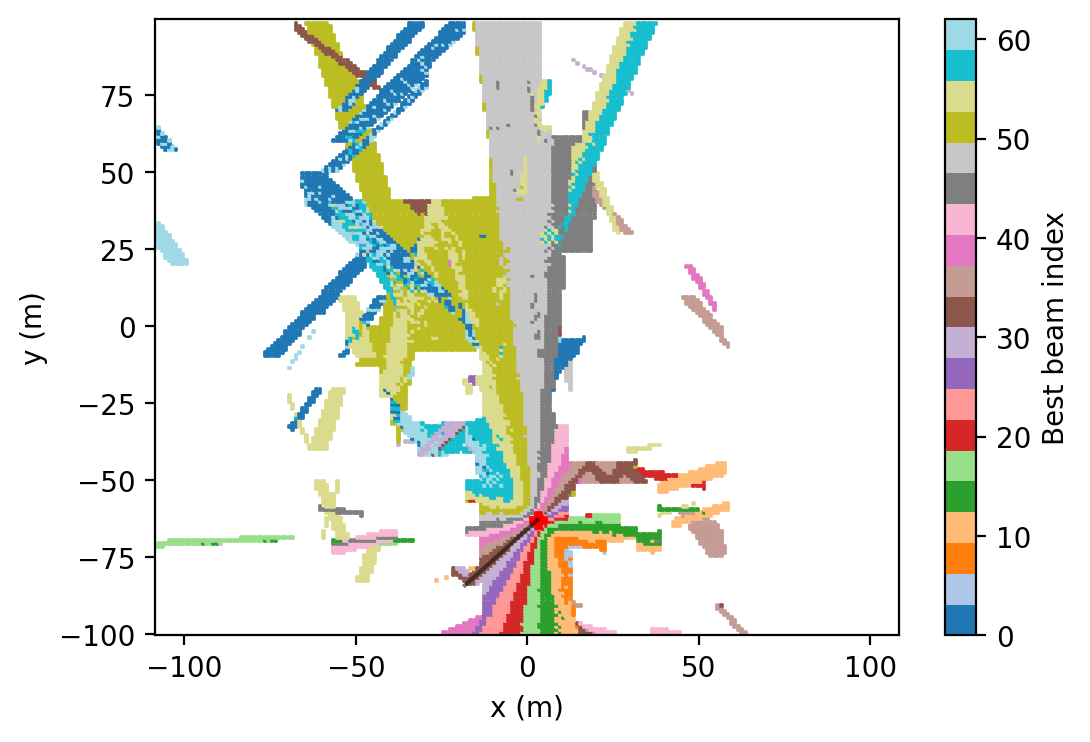

In [22]:
import os
os.chdir("/content")  # so ./scenarios resolves correctly

# import LWM's pipeline functions directly
from input_preprocess import DeepMIMO_data_gen, patch_gen, scenario_prop, tokenizer

props = scenario_prop()

# our three scenarios and their properties
SELECTED_SCENARIOS = {
    "city_11_santaclara": props["city_11_santaclara"],  # 32 ant, 32 SC
    "city_12_fortworth":  props["city_12_fortworth"],   # 32 ant, 64 SC
    "city_6_miami":       props["city_6_miami"],         # 16 ant, 32 SC
}

print("Scenario properties:")
for name, p in SELECTED_SCENARIOS.items():
    print(f"  {name}: n_ant_bs={p['n_ant_bs']}, n_subcarriers={p['n_subcarriers']}, "
          f"n_rows={p['n_rows']}, n_per_row={p['n_per_row']}")

# generate tokenized data for each scenario using LWM's tokenizer
# bs_idxs=[1] keeps it fast — we use 1 base station per scenario for now
# n_beams=64 to match the challenge data labels
# load_data=False means generate fresh from the .mat files

N_BEAMS = 64
tokenized_data  = {}
beam_labels     = {}
raw_channels    = {}

for sc_name in SELECTED_SCENARIOS:
    print(f"\n{'='*50}")
    print(f"Processing: {sc_name}")
    print(f"{'='*50}")
    try:
        patches, labels, raw_chs = tokenizer(
            selected_scenario_names=[sc_name],
            bs_idxs=[1],            # one BS to keep memory manageable
            load_data=False,
            task="Beam Prediction",
            n_beams=N_BEAMS,
            mask=False,             # no masking for downstream task
            seed=SEED
        )
        tokenized_data[sc_name] = patches
        beam_labels[sc_name]    = labels
        raw_channels[sc_name]   = raw_chs
        print(f"  patches shape: {patches.shape}")
        print(f"  labels shape:  {labels.shape}, range: {labels.min()}–{labels.max()}")
        print(f"  raw_chs shape: {raw_chs.shape}")
    except Exception as e:
        print(f"  ERROR: {e}")
        import traceback
        traceback.print_exc()

print("\nDone.")

In [23]:
from input_preprocess import (deepmimo_data_cleaning, patch_maker,
                               label_gen, scenario_prop, get_parameters)

def generate_scenario_with_row_fix(scenario_name, bs_idx=1, n_beams=64, seed=42):
    """
    Same as LWM's DeepMIMO_data_gen + label_gen pipeline but auto-detects
    the actual available row range from the .mat file instead of trusting
    scenario_prop, which has hardcoded values that don't match the HF subset files.
    """
    parameters, row_column_users = get_parameters(scenario_name, bs_idx)

    # --- find actual row count from the mat file ---
    import scipy.io as sio, glob
    ue_files = glob.glob(f"./scenarios/{scenario_name}/BS{bs_idx}_UE_*.mat")
    if not ue_files:
        raise FileNotFoundError(f"No UE mat file found for {scenario_name} BS{bs_idx}")

    mat = sio.loadmat(ue_files[0])
    n_users_actual = mat['channels'].shape[1]
    props = row_column_users[scenario_name]
    n_per_row = props['n_per_row']
    n_rows_actual = n_users_actual // n_per_row
    print(f"  Auto-detected rows: {n_rows_actual} (file has {n_users_actual} users, "
          f"{n_per_row} per row)")

    # override user_rows with what's actually available
    parameters['user_rows'] = np.arange(n_rows_actual)

    # generate channels
    print(f"  Running DeepMIMOv3...")
    deepmimo_dataset = DeepMIMOv3.generate_data(parameters)

    # uniform sampling (same as LWM's pipeline)
    from input_preprocess import uniform_sampling, select_by_idx
    if "O1" in scenario_name:
        hops = [2, 2]
    else:
        hops = [1, 1]
    uniform_idxs = uniform_sampling(
        deepmimo_dataset,
        hops,
        len(parameters['user_rows']),
        users_per_row=n_per_row
    )
    data = select_by_idx(deepmimo_dataset, uniform_idxs)[0]

    # clean → patch → label
    cleaned = deepmimo_data_cleaning(data)
    patches = patch_maker(cleaned, N_ROWS=4, N_COLUMNS=4)

    raw_chs = torch.tensor(cleaned).squeeze(1)
    raw_chs = raw_chs.view(raw_chs.size(0), -1)
    raw_chs = torch.hstack((raw_chs.real, raw_chs.imag))

    labels  = label_gen("Beam Prediction", data, scenario_name, n_beams=n_beams)

    # convert patches to torch same as tokenizer does
    patch_list = [torch.tensor(patches[i], dtype=torch.float32)
                  for i in range(len(patches))]

    # add CLS token (0.2 * ones) to front of each sample
    patch_size = patches.shape[-1]
    cls_token  = 0.2 * np.ones(patch_size)
    tokenized  = torch.stack([
        torch.tensor(np.vstack([cls_token, patches[i]]), dtype=torch.float32)
        for i in range(len(patches))
    ])

    return tokenized, torch.tensor(labels, dtype=torch.long), raw_chs


# --- run it for the two broken scenarios ---
for sc_name in ["city_11_santaclara", "city_12_fortworth"]:
    print(f"\n{'='*50}")
    print(f"Processing: {sc_name}")
    print(f"{'='*50}")
    try:
        patches, labels, raw_chs = generate_scenario_with_row_fix(
            sc_name, bs_idx=1, n_beams=N_BEAMS, seed=SEED
        )
        tokenized_data[sc_name] = patches
        beam_labels[sc_name]    = labels
        raw_channels[sc_name]   = raw_chs
        print(f"  patches shape: {patches.shape}")
        print(f"  labels shape:  {labels.shape}, range: {labels.min()}–{labels.max()}")
        print(f"  raw_chs shape: {raw_chs.shape}")
    except Exception as e:
        print(f"  ERROR: {e}")
        import traceback; traceback.print_exc()

print("\nAll scenarios:")
for sc, t in tokenized_data.items():
    print(f"  {sc}: {t.shape}")


Processing: city_11_santaclara
  Auto-detected rows: 18 (file has 5358 users, 285 per row)
  Running DeepMIMOv3...

Basestation 1

UE-BS Channels


Generating channels: 100%|██████████| 2052/2052 [00:01<00:00, 1881.51it/s]
Traceback (most recent call last):
  File "/tmp/ipykernel_1745/3371647009.py", line 78, in <cell line: 0>
    patches, labels, raw_chs = generate_scenario_with_row_fix(
                               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_1745/3371647009.py", line 45, in generate_scenario_with_row_fix
    data = select_by_idx(deepmimo_dataset, uniform_idxs)[0]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/LWM/input_preprocess.py", line 373, in select_by_idx
    dataset_t[bs_idx]['user'] = {k: dataset[bs_idx]['user'][k][idxs] for k in dataset[bs_idx]['user']}
                                    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^
IndexError: index 2052 is out of bounds for axis 0 with size 2052


  ERROR: index 2052 is out of bounds for axis 0 with size 2052

Processing: city_12_fortworth
  Auto-detected rows: 34 (file has 6192 users, 179 per row)
  Running DeepMIMOv3...

Basestation 1

UE-BS Channels


Generating channels: 100%|██████████| 2448/2448 [00:00<00:00, 4643.20it/s]

  ERROR: index 2448 is out of bounds for axis 0 with size 2448

All scenarios:
  city_6_miami: torch.Size([10441, 33, 32])



Traceback (most recent call last):
  File "/tmp/ipykernel_1745/3371647009.py", line 78, in <cell line: 0>
    patches, labels, raw_chs = generate_scenario_with_row_fix(
                               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_1745/3371647009.py", line 45, in generate_scenario_with_row_fix
    data = select_by_idx(deepmimo_dataset, uniform_idxs)[0]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/LWM/input_preprocess.py", line 373, in select_by_idx
    dataset_t[bs_idx]['user'] = {k: dataset[bs_idx]['user'][k][idxs] for k in dataset[bs_idx]['user']}
                                    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^
IndexError: index 2448 is out of bounds for axis 0 with size 2448


In [24]:
def generate_scenario_no_sampling(scenario_name, bs_idx=1, n_beams=64, seed=42):
    """
    Simplified pipeline that skips uniform_sampling entirely.
    Uses all available users in the downloaded scenario file.
    Fixes the index-out-of-bounds error caused by HF subset files
    having fewer rows than scenario_prop expects.
    """
    parameters, row_column_users = get_parameters(scenario_name, bs_idx)
    props = row_column_users[scenario_name]

    # detect actual row count from the mat file
    import scipy.io as sio, glob
    ue_files = glob.glob(f"./scenarios/{scenario_name}/BS{bs_idx}_UE_*.mat")
    mat = sio.loadmat(ue_files[0])
    n_users_actual = mat['channels'].shape[1]
    n_per_row = props['n_per_row']
    n_rows_actual = n_users_actual // n_per_row
    print(f"  {n_users_actual} users, {n_rows_actual} rows × {n_per_row} per row")

    # clamp user_rows to what's actually available
    parameters['user_rows'] = np.arange(n_rows_actual)

    # generate channels
    print(f"  Running DeepMIMOv3...")
    deepmimo_dataset = DeepMIMOv3.generate_data(parameters)

    # use ALL generated users — no uniform subsampling
    # deepmimo_dataset[0] is BS index 0 (we have 1 active BS)
    data = deepmimo_dataset[0]
    n_generated = data['user']['channel'].shape[0]
    print(f"  DeepMIMOv3 generated {n_generated} users")

    # clean (remove zero-channel users)
    cleaned = deepmimo_data_cleaning(data)
    print(f"  After cleaning: {len(cleaned)} users")

    # patch tokenization
    patches = patch_maker(cleaned, N_ROWS=4, N_COLUMNS=4)

    # raw channels (real + imag flattened)
    raw_chs = torch.tensor(cleaned).squeeze(1)
    raw_chs = raw_chs.view(raw_chs.size(0), -1)
    raw_chs = torch.hstack((raw_chs.real, raw_chs.imag))

    # beam labels using LWM's steering vector codebook
    labels = label_gen("Beam Prediction", data, scenario_name, n_beams=n_beams)

    # add CLS token to front of each sample (same as LWM tokenizer)
    patch_size = patches.shape[-1]
    cls_token  = 0.2 * np.ones(patch_size)
    tokenized  = torch.stack([
        torch.tensor(np.vstack([cls_token, patches[i]]), dtype=torch.float32)
        for i in range(len(patches))
    ])

    return tokenized, torch.tensor(labels, dtype=torch.long), raw_chs


# run for the two remaining scenarios
for sc_name in ["city_11_santaclara", "city_12_fortworth"]:
    print(f"\n{'='*50}")
    print(f"Processing: {sc_name}")
    print(f"{'='*50}")
    try:
        patches, labels, raw_chs = generate_scenario_no_sampling(
            sc_name, bs_idx=1, n_beams=N_BEAMS, seed=SEED
        )
        tokenized_data[sc_name] = patches
        beam_labels[sc_name]    = labels
        raw_channels[sc_name]   = raw_chs
        print(f"  patches shape: {patches.shape}")
        print(f"  labels shape:  {labels.shape}, range: {labels.min()}–{labels.max()}")
        print(f"  raw_chs shape: {raw_chs.shape}")
    except Exception as e:
        print(f"  ERROR: {e}")
        import traceback; traceback.print_exc()

print("\nFinal scenario inventory:")
for sc, t in tokenized_data.items():
    print(f"  {sc}: {t.shape}, labels: {beam_labels[sc].shape}")


Processing: city_11_santaclara
  5358 users, 18 rows × 285 per row
  Running DeepMIMOv3...

Basestation 1

UE-BS Channels


Generating channels: 100%|██████████| 2052/2052 [00:01<00:00, 1248.06it/s]
Traceback (most recent call last):
  File "/tmp/ipykernel_1745/3623338603.py", line 65, in <cell line: 0>
    patches, labels, raw_chs = generate_scenario_no_sampling(
                               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_1745/3623338603.py", line 38, in generate_scenario_no_sampling
    patches = patch_maker(cleaned, N_ROWS=4, N_COLUMNS=4)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: patch_maker() got an unexpected keyword argument 'N_ROWS'


  DeepMIMOv3 generated 2052 users
  After cleaning: 1104 users
  ERROR: patch_maker() got an unexpected keyword argument 'N_ROWS'

Processing: city_12_fortworth
  6192 users, 34 rows × 179 per row
  Running DeepMIMOv3...

Basestation 1

UE-BS Channels


Generating channels: 100%|██████████| 2448/2448 [00:02<00:00, 858.33it/s] 

  DeepMIMOv3 generated 2448 users
  After cleaning: 1113 users
  ERROR: patch_maker() got an unexpected keyword argument 'N_ROWS'

Final scenario inventory:
  city_6_miami: torch.Size([10441, 33, 32]), labels: torch.Size([10441])



Traceback (most recent call last):
  File "/tmp/ipykernel_1745/3623338603.py", line 65, in <cell line: 0>
    patches, labels, raw_chs = generate_scenario_no_sampling(
                               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_1745/3623338603.py", line 38, in generate_scenario_no_sampling
    patches = patch_maker(cleaned, N_ROWS=4, N_COLUMNS=4)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: patch_maker() got an unexpected keyword argument 'N_ROWS'



Processing: city_11_santaclara

Basestation 1

UE-BS Channels


Generating channels: 100%|██████████| 2052/2052 [00:00<00:00, 2407.50it/s]


  After cleaning: 1104 users


Computing the channel for each user: 100%|██████████| 2052/2052 [00:00<00:00, 4403.18it/s]


  patches shape: torch.Size([1104, 65, 32])
  labels shape:  torch.Size([1104]), range: 0–61

Processing: city_12_fortworth

Basestation 1

UE-BS Channels


Generating channels: 100%|██████████| 2448/2448 [00:00<00:00, 4048.01it/s]


  After cleaning: 1113 users


Computing the channel for each user: 100%|██████████| 2448/2448 [00:00<00:00, 2985.87it/s]


  patches shape: torch.Size([1113, 129, 32])
  labels shape:  torch.Size([1113]), range: 0–59

Final scenario inventory:
  city_6_miami: torch.Size([10441, 33, 32]), labels: torch.Size([10441])
  city_11_santaclara: torch.Size([1104, 65, 32]), labels: torch.Size([1104])
  city_12_fortworth: torch.Size([1113, 129, 32]), labels: torch.Size([1113])


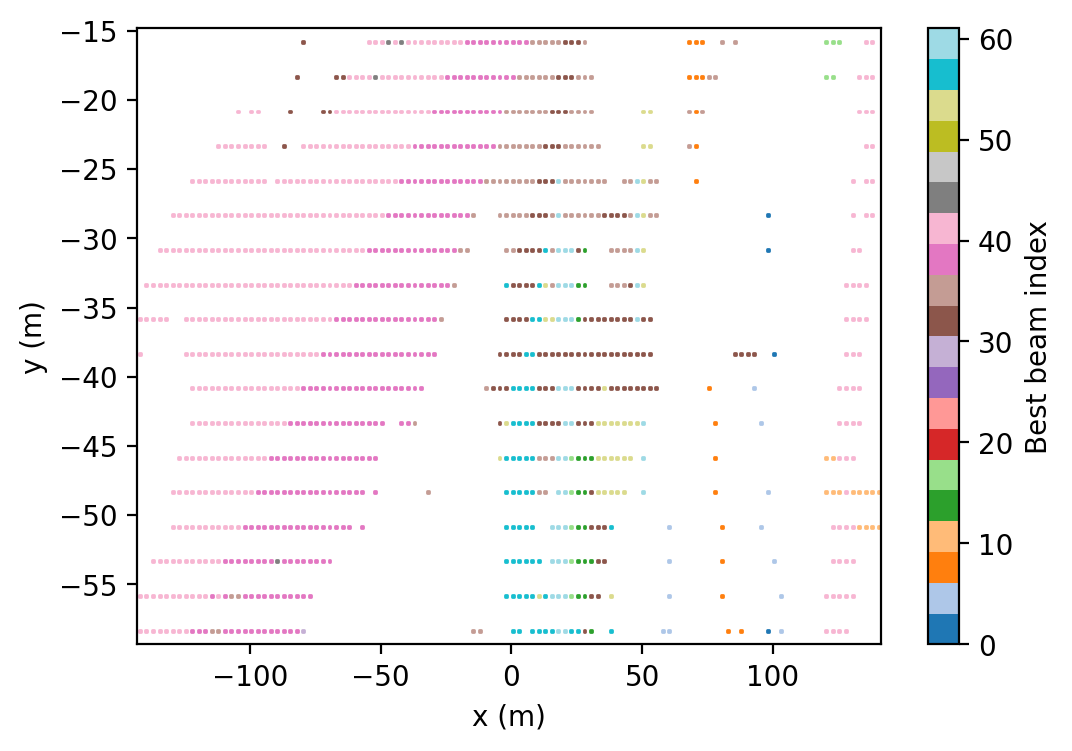

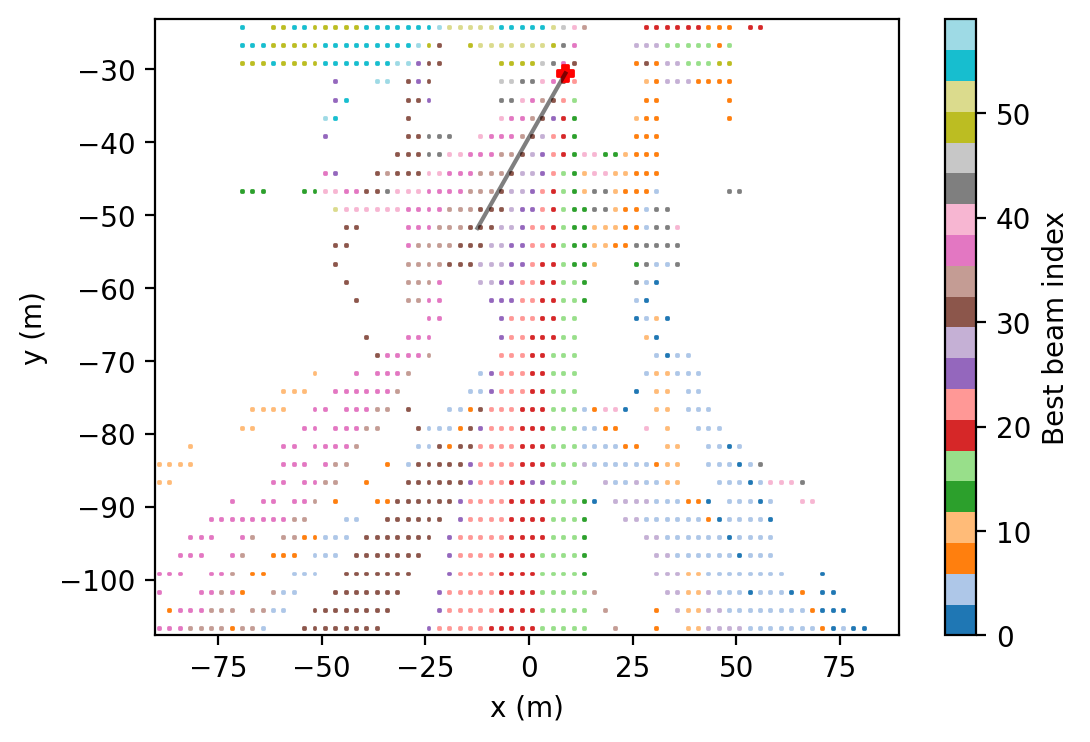

In [25]:
# one-line fix: patch_maker(cleaned, 4, 4) not patch_maker(cleaned, N_ROWS=4, N_COLUMNS=4)

for sc_name in ["city_11_santaclara", "city_12_fortworth"]:
    print(f"\n{'='*50}")
    print(f"Processing: {sc_name}")
    print(f"{'='*50}")
    try:
        parameters, row_column_users = get_parameters(sc_name, 1)
        props = row_column_users[sc_name]

        import scipy.io as sio, glob
        ue_files = glob.glob(f"./scenarios/{sc_name}/BS1_UE_*.mat")
        mat = sio.loadmat(ue_files[0])
        n_users_actual = mat['channels'].shape[1]
        n_per_row = props['n_per_row']
        n_rows_actual = n_users_actual // n_per_row
        parameters['user_rows'] = np.arange(n_rows_actual)

        deepmimo_dataset = DeepMIMOv3.generate_data(parameters)
        data    = deepmimo_dataset[0]
        cleaned = deepmimo_data_cleaning(data)
        print(f"  After cleaning: {len(cleaned)} users")

        patches = patch_maker(cleaned, 4, 4)   # positional args

        raw_chs = torch.tensor(cleaned).squeeze(1)
        raw_chs = raw_chs.view(raw_chs.size(0), -1)
        raw_chs = torch.hstack((raw_chs.real, raw_chs.imag))

        labels  = label_gen("Beam Prediction", data, sc_name, n_beams=N_BEAMS)

        patch_size = patches.shape[-1]
        cls_token  = 0.2 * np.ones(patch_size)
        tokenized  = torch.stack([
            torch.tensor(np.vstack([cls_token, patches[i]]), dtype=torch.float32)
            for i in range(len(patches))
        ])

        tokenized_data[sc_name] = tokenized
        beam_labels[sc_name]    = torch.tensor(labels, dtype=torch.long)
        raw_channels[sc_name]   = raw_chs

        print(f"  patches shape: {tokenized.shape}")
        print(f"  labels shape:  {beam_labels[sc_name].shape}, "
              f"range: {beam_labels[sc_name].min()}–{beam_labels[sc_name].max()}")

    except Exception as e:
        print(f"  ERROR: {e}")
        import traceback; traceback.print_exc()

print("\nFinal scenario inventory:")
for sc, t in tokenized_data.items():
    print(f"  {sc}: {t.shape}, labels: {beam_labels[sc].shape}")

## Section 5 — Save Processed Data to Drive & Log to W&B

Save all three tokenized scenario tensors to Drive so every subsequent
notebook can load them without re-running DeepMIMOv3.
Also log dataset statistics to W&B.

In [26]:
import pickle

PROC_SAVE_DIR = DRIVE_ROOT / "data" / "processed"
PROC_SAVE_DIR.mkdir(parents=True, exist_ok=True)

print("Saving processed scenario data to Drive...")
print("=" * 55)

scenario_meta = {}
for sc_name, patches in tokenized_data.items():
    labels  = beam_labels[sc_name]
    raw_chs = raw_channels[sc_name]

    save_path = PROC_SAVE_DIR / f"{sc_name}.pt"
    torch.save({
        "patches":  patches,    # (n_samples, n_patches+1, patch_size)
        "labels":   labels,     # (n_samples,)
        "raw_chs":  raw_chs,    # (n_samples, 2*n_ant*n_sc)
        "sc_name":  sc_name,
        "n_beams":  N_BEAMS,
        "seed":     SEED,
    }, str(save_path))

    size_mb = save_path.stat().st_size / 1e6
    n_samples   = len(patches)
    seq_len     = patches.shape[1]   # n_patches + 1 CLS token
    patch_size  = patches.shape[2]
    n_unique    = len(torch.unique(labels))

    scenario_meta[sc_name] = {
        "n_samples":  n_samples,
        "seq_len":    seq_len,
        "patch_size": patch_size,
        "n_unique_beams": int(n_unique),
        "label_min":  int(labels.min()),
        "label_max":  int(labels.max()),
        "size_mb":    round(size_mb, 2),
    }

    print(f"{sc_name}")
    print(f"  samples={n_samples}, seq_len={seq_len}, "
          f"patch_size={patch_size}, unique_beams={n_unique}")
    print(f"  saved → {save_path} ({size_mb:.2f} MB)")

# also save the pre-processed challenge data (scenario A baseline)
challenge_save = PROC_SAVE_DIR / "beam_challenge.pt"
torch.save({
    "train_data":   torch.tensor(bp_train_data,   dtype=torch.float32),
    "train_labels": bp_train_labels,
    "test_data":    torch.tensor(bp_test_data,    dtype=torch.float32),
    "n_beams":      N_BEAMS,
}, str(challenge_save))
print(f"\nbeam_challenge saved → {challenge_save} "
      f"({challenge_save.stat().st_size/1e6:.2f} MB)")

# log summary table to W&B
rows = [[k] + list(v.values()) for k, v in scenario_meta.items()]
cols = ["scenario"] + list(list(scenario_meta.values())[0].keys())
wandb.log({
    "dataset/scenario_summary": wandb.Table(columns=cols, data=rows)
})

wandb.config.update({
    "scenarios_generated": list(tokenized_data.keys()),
    "n_beams": N_BEAMS,
    "variable_seq_lengths": [tokenized_data[s].shape[1]
                              for s in tokenized_data],
})

print("\nAll data saved and logged to W&B.")

Saving processed scenario data to Drive...
city_6_miami
  samples=10441, seq_len=33, patch_size=32, unique_beams=63
  saved → /content/drive/MyDrive/6g-lwm-beam-prediction/data/processed/city_6_miami.pt (131.06 MB)
city_11_santaclara
  samples=1104, seq_len=65, patch_size=32, unique_beams=35
  saved → /content/drive/MyDrive/6g-lwm-beam-prediction/data/processed/city_11_santaclara.pt (18.24 MB)
city_12_fortworth
  samples=1113, seq_len=129, patch_size=32, unique_beams=59
  saved → /content/drive/MyDrive/6g-lwm-beam-prediction/data/processed/city_12_fortworth.pt (36.62 MB)

beam_challenge saved → /content/drive/MyDrive/6g-lwm-beam-prediction/data/processed/beam_challenge.pt (12.76 MB)

All data saved and logged to W&B.


## Section 6 — Dataset Visualization & W&B Logging

Plot beam distributions and sequence length comparison across all three scenarios.
These go into the W&B dashboard as the first logged artifacts of the project.

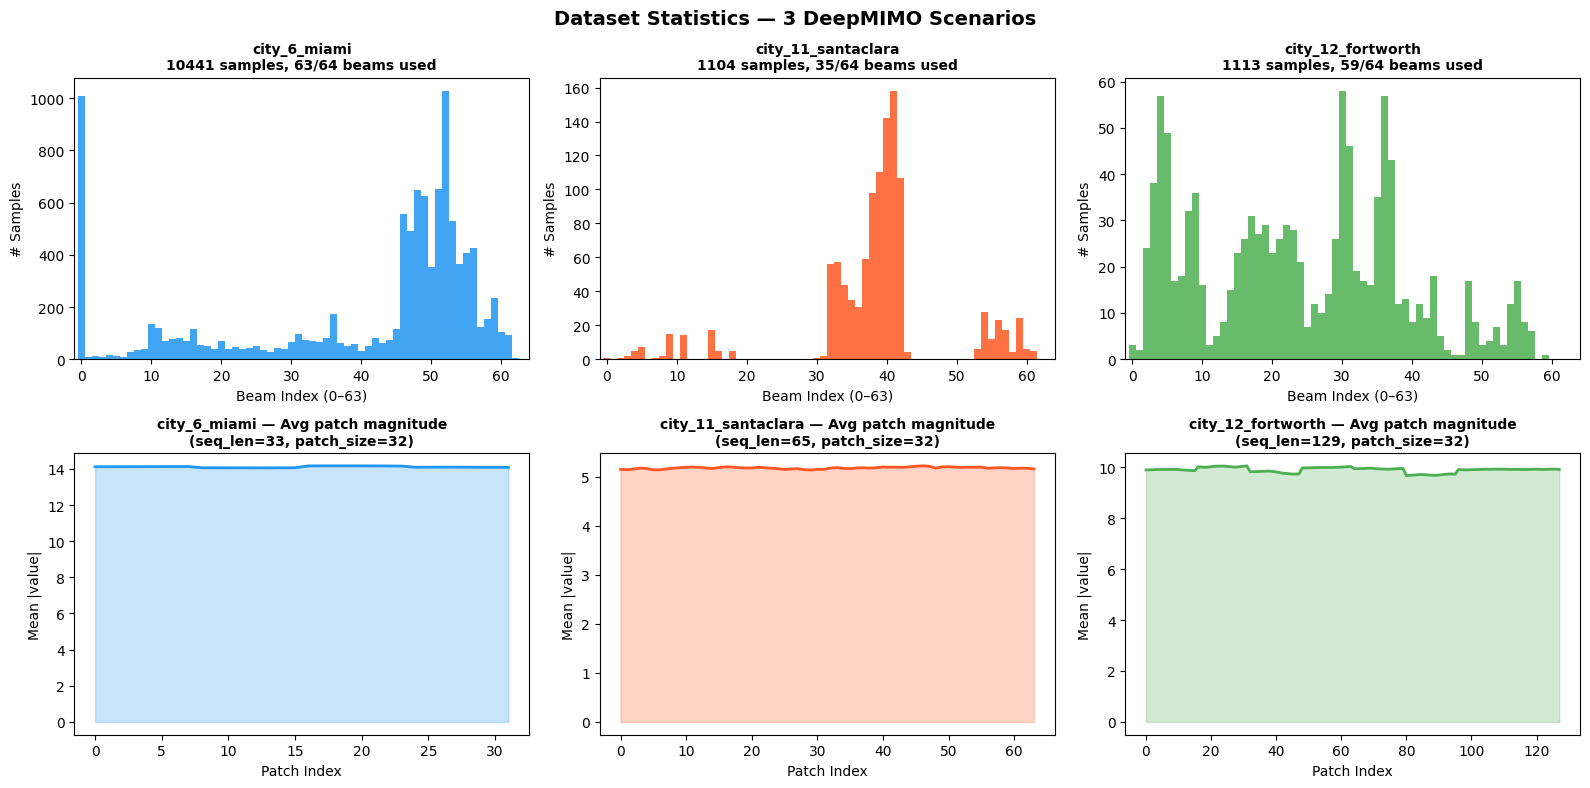

Figure saved and logged to W&B.


In [27]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle("Dataset Statistics — 3 DeepMIMO Scenarios",
             fontsize=14, fontweight="bold")

palette = ["#2196F3", "#FF5722", "#4CAF50"]

for i, (sc_name, patches) in enumerate(tokenized_data.items()):
    labels  = beam_labels[sc_name]
    n_beams_used = scenario_meta[sc_name]["n_unique_beams"]
    seq_len      = scenario_meta[sc_name]["seq_len"]
    n_ant        = (seq_len - 1) // 2   # rough antenna estimate from seq_len

    # top row: beam distribution
    ax = axes[0, i]
    beam_counts = torch.bincount(labels, minlength=N_BEAMS).numpy()
    ax.bar(range(N_BEAMS), beam_counts, color=palette[i], alpha=0.85, width=1.0)
    ax.set_title(f"{sc_name}\n{len(labels)} samples, {n_beams_used}/64 beams used",
                 fontweight="bold", fontsize=10)
    ax.set_xlabel("Beam Index (0–63)")
    ax.set_ylabel("# Samples")
    ax.set_xlim(-1, N_BEAMS)

    # bottom row: average patch magnitude across token positions
    ax2 = axes[1, i]
    # mean absolute value per token position, averaged across samples
    patch_mag = patches[:, 1:, :].abs().mean(dim=(0, 2)).numpy()  # skip CLS
    ax2.plot(patch_mag, color=palette[i], linewidth=2)
    ax2.fill_between(range(len(patch_mag)), patch_mag, alpha=0.25, color=palette[i])
    ax2.set_title(f"{sc_name} — Avg patch magnitude\n(seq_len={seq_len}, "
                  f"patch_size=32)", fontweight="bold", fontsize=10)
    ax2.set_xlabel("Patch Index")
    ax2.set_ylabel("Mean |value|")

plt.tight_layout()
fig_path = FIG_DIR / "01_dataset_statistics.png"
plt.savefig(str(fig_path), dpi=150, bbox_inches="tight")
plt.show()
wandb.log({"dataset/statistics": wandb.Image(str(fig_path))})
print(f"Figure saved and logged to W&B.")

In [28]:
# final summary printout and W&B run close

print("=" * 55)
print("DAY 1 COMPLETE — Summary")
print("=" * 55)
print(f"\nThree scenarios tokenized and saved to Drive:")
for sc_name, meta in scenario_meta.items():
    print(f"  {sc_name}")
    print(f"    samples={meta['n_samples']}, seq_len={meta['seq_len']}, "
          f"patch_size={meta['patch_size']}, size={meta['size_mb']} MB")

print(f"\nPre-processed challenge data saved (train=622, test=2491)")
print(f"\nData format: torch tensors (n_samples, seq_len, 32)")
print(f"  seq_len varies by scenario — LWM v1.1 handles this natively")
print(f"  CLS token prepended at position 0 (same as LWM training format)")

print(f"\nVariable sequence lengths:")
print(f"  city_6_miami      → seq_len=33  (16 ant × 32 SC → 16 patches + CLS)")
print(f"  city_11_santaclara → seq_len=65  (32 ant × 32 SC → 64 patches + CLS)")
print(f"  city_12_fortworth  → seq_len=129 (32 ant × 64 SC → 128 patches + CLS)")

print(f"\nW&B project: https://wandb.ai/nabeegh-khan-university-of-toronto/"
      f"6g-lwm-beam-prediction")

print(f"\nNext — Notebook 02:")
print(f"  Load LWM model weights from /content/LWM/models/model.pth")
print(f"  Run inference → extract CLS embeddings for all three scenarios")
print(f"  Train MLP baseline head, log top-1 and top-3 accuracy to W&B")

wandb.finish()
print("\nW&B run closed.")

DAY 1 COMPLETE — Summary

Three scenarios tokenized and saved to Drive:
  city_6_miami
    samples=10441, seq_len=33, patch_size=32, size=131.06 MB
  city_11_santaclara
    samples=1104, seq_len=65, patch_size=32, size=18.24 MB
  city_12_fortworth
    samples=1113, seq_len=129, patch_size=32, size=36.62 MB

Pre-processed challenge data saved (train=622, test=2491)

Data format: torch tensors (n_samples, seq_len, 32)
  seq_len varies by scenario — LWM v1.1 handles this natively
  CLS token prepended at position 0 (same as LWM training format)

Variable sequence lengths:
  city_6_miami      → seq_len=33  (16 ant × 32 SC → 16 patches + CLS)
  city_11_santaclara → seq_len=65  (32 ant × 32 SC → 64 patches + CLS)
  city_12_fortworth  → seq_len=129 (32 ant × 64 SC → 128 patches + CLS)

W&B project: https://wandb.ai/nabeegh-khan-university-of-toronto/6g-lwm-beam-prediction

Next — Notebook 02:
  Load LWM model weights from /content/LWM/models/model.pth
  Run inference → extract CLS embeddings 


W&B run closed.
